In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
df=pd.read_csv("StudentsPerformance.csv")

In [28]:
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [29]:
df.shape

(1000, 8)

In [30]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [31]:
df.tail()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77
999,female,group D,some college,free/reduced,none,77,86,86


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [33]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [34]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [35]:
df.duplicated().sum()

np.int64(0)

\Average scores by parental education:
                             math score  reading score  writing score
parental level of education                                          
associate's degree            67.882883      70.927928      69.896396
bachelor's degree             69.389831      73.000000      73.381356
high school                   62.137755      64.704082      62.448980
master's degree               69.745763      75.372881      75.677966
some college                  67.128319      69.460177      68.840708
some high school              63.497207      66.938547      64.888268


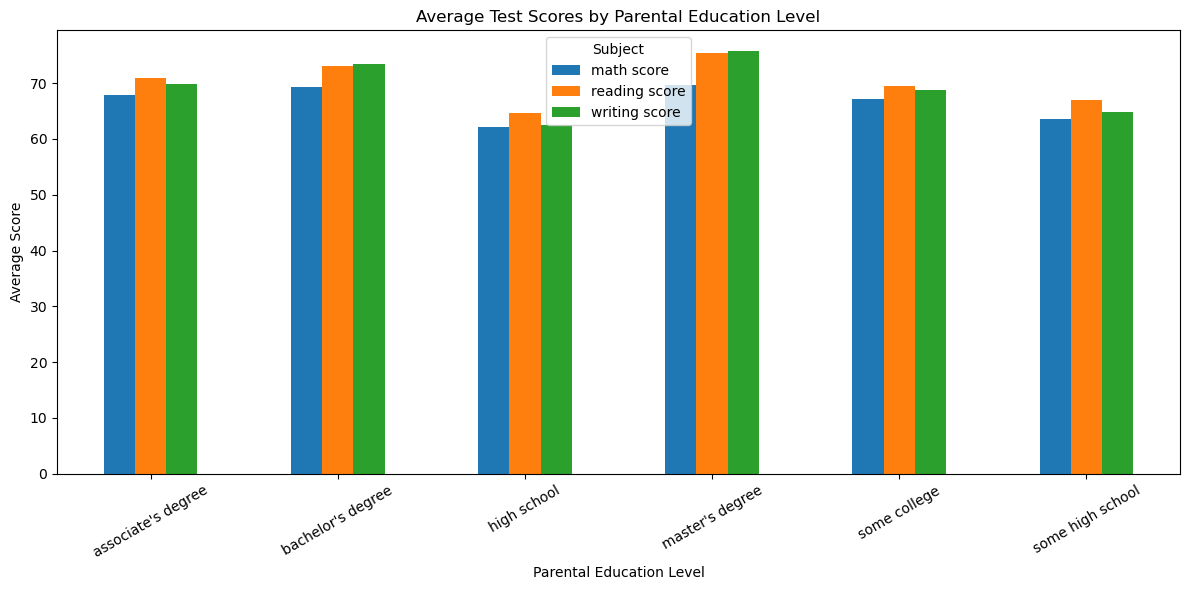

In [36]:
parental_avg=df.groupby("parental level of education")[
    ["math score","reading score","writing score"]
    ].mean()

print("\Average scores by parental education:")
print(parental_avg)

parental_avg.plot(
    kind="bar",
    figsize=(12,6)
)
plt.title("Average Test Scores by Parental Education Level")
plt.xlabel("Parental Education Level")
plt.ylabel("Average Score")
plt.xticks(rotation=30)
plt.legend(title="Subject")
plt.tight_layout()
plt.show()

\Average scores by parental education:
                             math score  reading score  writing score
parental level of education                                          
associate's degree            67.882883      70.927928      69.896396
bachelor's degree             69.389831      73.000000      73.381356
high school                   62.137755      64.704082      62.448980
master's degree               69.745763      75.372881      75.677966
some college                  67.128319      69.460177      68.840708
some high school              63.497207      66.938547      64.888268


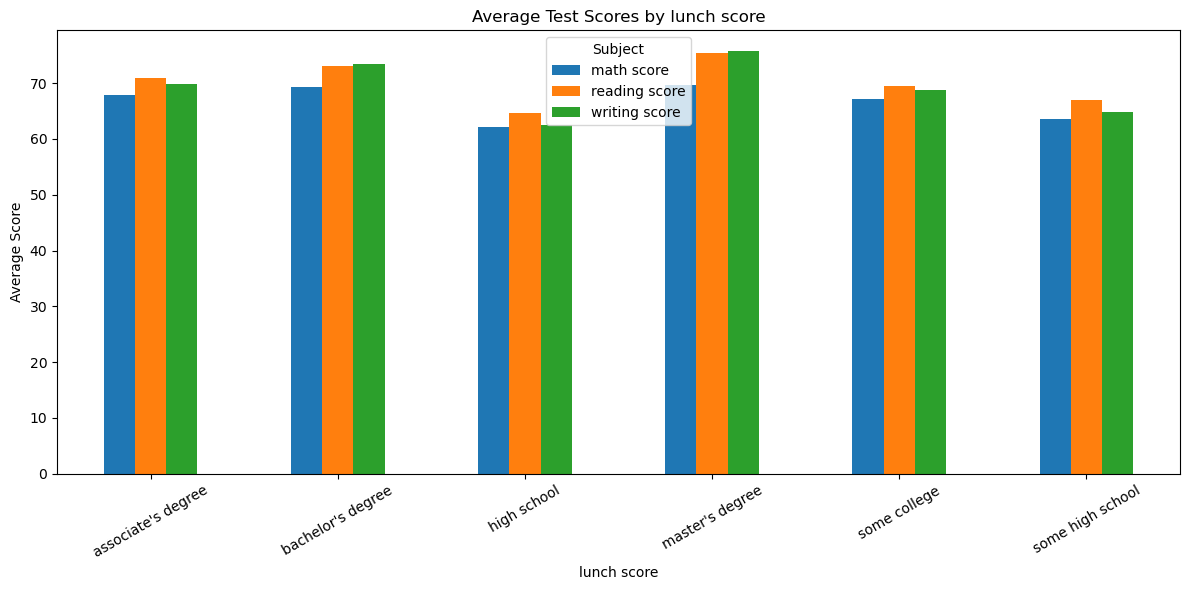

In [37]:
lunch_avg=df.groupby("parental level of education")[
    ["math score","reading score","writing score"]
    ].mean()

print("\Average scores by parental education:")
print(lunch_avg)

lunch_avg.plot(
    kind="bar",
    figsize=(12,6)
)
plt.title("Average Test Scores by lunch score")
plt.xlabel("lunch score")
plt.ylabel("Average Score")
plt.xticks(rotation=30)
plt.legend(title="Subject")
plt.tight_layout()
plt.show()

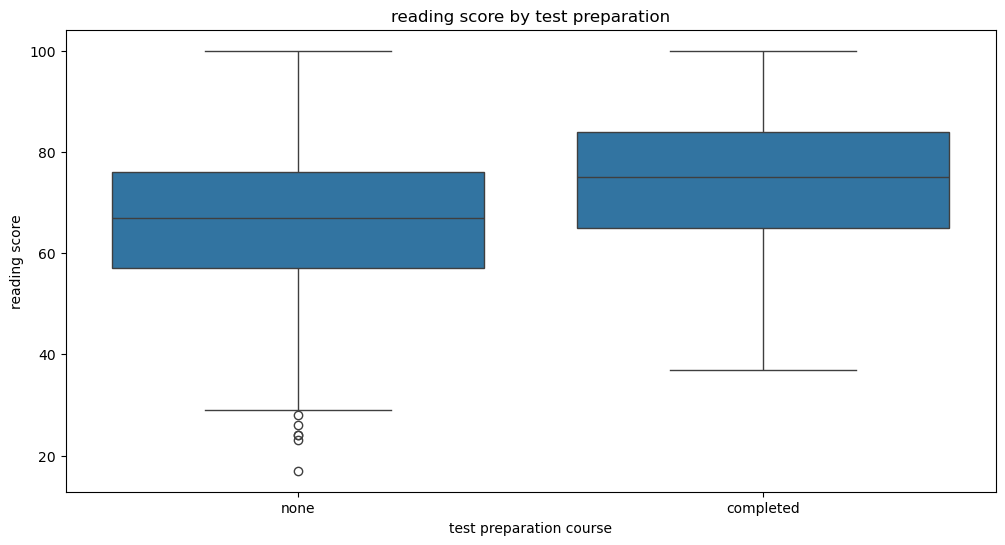

In [38]:
plt.figure(figsize=(12,6))
sns.boxplot(
    data=df,
    x="test preparation course",
    y="reading score"
)

plt.title("reading score by test preparation")
plt.xlabel("test preparation course")
plt.ylabel("reading score")
plt.show()

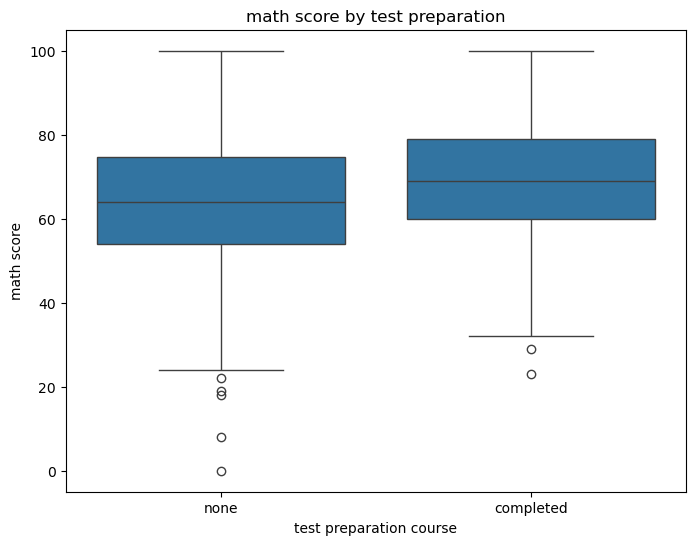

In [39]:
plt.figure(figsize=(8,6))
sns.boxplot(
    data=df,
    x="test preparation course",
    y="math score"
)

plt.title("math score by test preparation")
plt.xlabel("test preparation course")
plt.ylabel("math score")
plt.show()

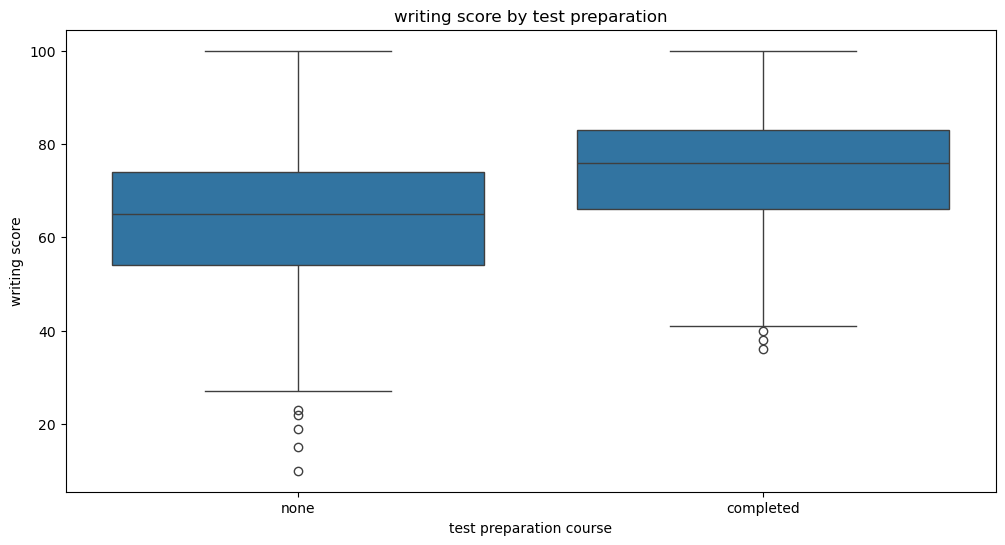

In [40]:
plt.figure(figsize=(12,6))
sns.boxplot(
    data=df,
    x="test preparation course",
    y="writing score"
)

plt.title("writing score by test preparation")
plt.xlabel("test preparation course")
plt.ylabel("writing score")
plt.show()

In [41]:
numeric_cols=["math score","reading score","writing score"]
correlation=df[numeric_cols].corr()
correlation

,math score,reading score,writing score
math score,1.000000,0.817580,0.802642
reading score,0.817580,1.000000,0.954598
writing score,0.802642,0.954598,1.000000


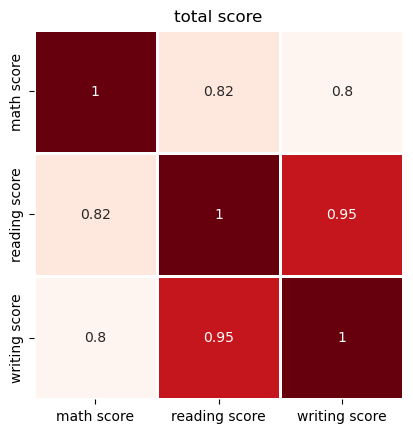

In [42]:
sns.heatmap(correlation,
            annot=True,
            cmap="Reds",
            cbar=False,
            square=True,
            linewidth=1)
plt.title("total score")
plt.show()


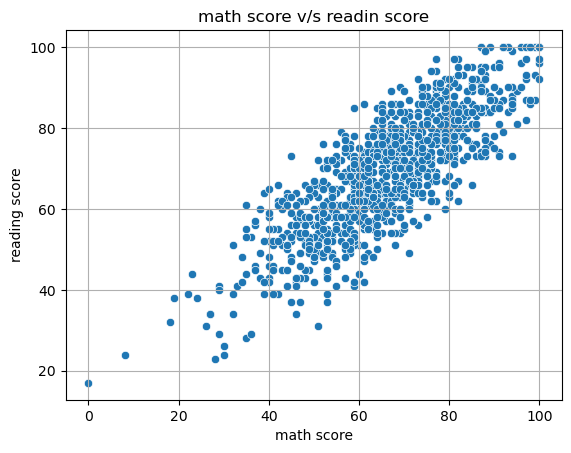

In [43]:
sns.scatterplot(x="math score",y="reading score",data=df)
plt.title("math score v/s readin score")
plt.xlabel("math score")
plt.ylabel("reading score")
plt.grid(True)
plt.show()

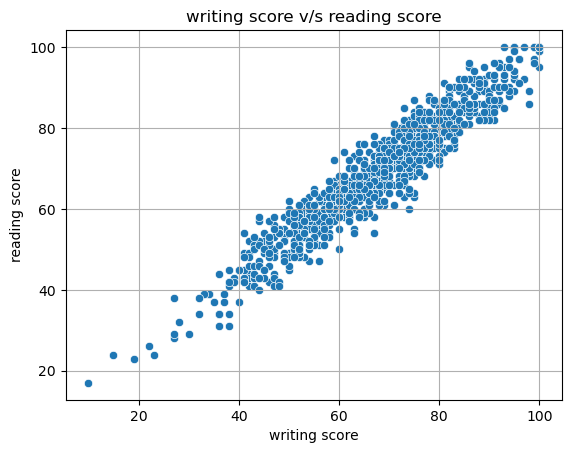

In [44]:
sns.scatterplot(x="writing score",y="reading score",data=df)
plt.title("writing score v/s reading score")
plt.xlabel("writing score")
plt.ylabel("reading score")
plt.grid(True)
plt.show()

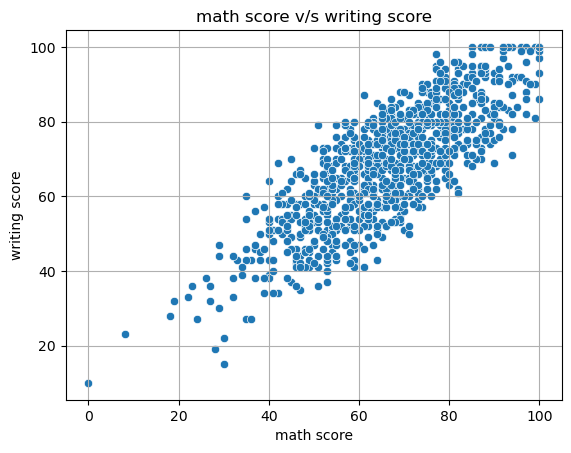

In [45]:
sns.scatterplot(x="math score",y="writing score",data=df)
plt.title("math score v/s writing score")
plt.xlabel("math score")
plt.ylabel("writing score")
plt.grid(True)
plt.show()